In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

WELL_CONFIGS = [
    {'well_name': 'well_1', 'file_path': r"C:\Users\Amin\Downloads\data\data\Section 1\well_01_DHP_data..csv",
     'ts_col': 'timestamp', 'pr_col': 'dhp'},
    {'well_name': 'well_2', 'file_path': r"C:\Users\Amin\Downloads\data\data\Section 1\well_02_DHP_data..csv",
     'ts_col': 'timestamp', 'pr_col': 'dhp'},
    {'well_name': 'well_3', 'file_path': r"C:\Users\Amin\Downloads\data\data\Section 1\well_03_DHP_data..csv",
     'ts_col': 'Timestamp', 'pr_col': 'DHP'},   
]

# task kriteriyalari
min_rise_psi   = 600   # en az 600 psi artis
min_duration_h = 2     # en az 2 saat davamliliq

# signal processing parameters
median_window = '20min'   # noise temizleme (median filter)
mean_window   = '10min'   # additional smoothing
noise_mult    = 4.0       # decline_tol = noise_mult * approximate noise
min_decline_tol = 15.0    # decline_tol bu deyerin altina dusmesin

# outlier temizleme 
outlier_window     = 5      # nece qonsu noqte ile lokal medyan hesablanacaq
outlier_threshold  = 500    # lokal medyandan bu qeder (psi) uzaqlasan noqteler atilir

# stagnation limit (hereketsizlik limiti)
max_stagnant_hours = 6 #eger 6 saatdan artiq artis olmadan zaman kecerse PBU sifirlanir
min_valid_psi=100
trough_reset_hours=3

In [2]:

def remove_outliers(df, pr_col='pressure', window=outlier_window, threshold_psi=outlier_threshold): #outlier deyerleri silme
    local_median = df[pr_col].rolling(window, center=True, min_periods=1).median()
    deviation = (df[pr_col] - local_median).abs()
    mask = deviation > threshold_psi
    n_out = int(mask.sum())
    if n_out:
        df = df.loc[~mask].copy()
    return df


def load_well_data(filepath, ts_col, pr_col):
    try:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col], engine='pyarrow')
    except Exception:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col])

    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')

    #menfi sonsuzluq olan deyerleri silme
    n_inf = np.isinf(df[pr_col]).sum()
    if n_inf: 
        df.loc[np.isinf(df[pr_col]), pr_col] = np.nan

    #NaN olan tezyiq deyerlerini silme
    n_nan_pressure = df[pr_col].isna().sum() 
    if n_nan_pressure:
        df = df.dropna(subset=[pr_col])

    #kecersiz olan <100 psi tezyiq deyerlerini sil
    n_floor = int((df[pr_col] < min_valid_psi).sum())
    if n_floor: 
        df = df[df[pr_col] >= min_valid_psi]

    df[pr_col] = df[pr_col].astype('float32')

    #datasetde olan zaman deyerlerinin bezilerinin sonunda qalan "T" herfini silib normal datetime formatına salma
    ts_raw = df[ts_col].astype(str).str.strip()
    ts_raw = ts_raw.str.replace(r'(\d)T$', r'\1', regex=True)
    df[ts_col] = pd.to_datetime(ts_raw, format="mixed", errors='coerce')

    n_bad_ts = df[ts_col].isna().sum() #ayrışdırıla bilmeyen tarix deyerlerini silme
    if n_bad_ts:
        df = df.dropna(subset=[ts_col])

    df = df.rename(columns={ts_col: 'timestamp', pr_col: 'pressure'})
    df = (df.sort_values('timestamp')
            .drop_duplicates(subset='timestamp')
            .set_index('timestamp'))

    df = remove_outliers(df)
    return df


def smooth_pressure(df, med_win=median_window, mean_win=mean_window):
    s = df['pressure'].rolling(med_win, min_periods=1).median()
    s = s.rolling(mean_win, min_periods=1).mean()
    return s.astype('float32')


def estimate_noise_level(smoothed, window='15min', quantile=0.2):
    rolling_std = smoothed.rolling(window, min_periods=5).std()
    noise = rolling_std.quantile(quantile)
    if pd.isna(noise) or noise <= 0:
        noise = smoothed.diff().abs().median() * 3
    return float(noise)


def detect_pbus_zigzag(smoothed, decline_tol, min_rise=min_rise_psi,
                        min_duration_hours=min_duration_h,
                        max_stagnant_hours=max_stagnant_hours,
                        trough_reset_hours=trough_reset_hours):
    idx = smoothed.index
    vals = smoothed.values
    n = len(vals)
    max_stagnant = pd.Timedelta(hours=max_stagnant_hours)
    trough_reset = pd.Timedelta(hours=trough_reset_hours)

    results = []
    trough_i, trough_v = 0, vals[0]
    peak_i,   peak_v   = 0, vals[0]
    last_move_i = 0
    state = 'seeking'

    for i in range(1, n):
        v = vals[i]

        if state == 'seeking':
            if v - trough_v >= decline_tol:
                peak_v, peak_i = v, i
                last_move_i = i
                state = 'rising'
            elif v <= trough_v:
                trough_v, trough_i = v, i
            elif (idx[i] - idx[trough_i]) > trough_reset:
                trough_v, trough_i = v, i

        elif state == 'rising':
            closed = False

            if v > peak_v:
                peak_v, peak_i = v, i
                last_move_i = i

            elif peak_v - v >= decline_tol:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'
                closed = True

            if not closed and (idx[i] - idx[last_move_i]) > max_stagnant:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'

    return pd.DataFrame(results)


def plot_all_pbus(df, result_df, well_name, max_points=200_000):
    sample_step = max(1, len(df) // max_points)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df.index[::sample_step], df['pressure'].values[::sample_step],
            color='steelblue', lw=0.6, label='raw data')
    for _, row in result_df.iterrows():
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)
    ax.set_title(f'{well_name} — all detected PBUs ({len(result_df)})')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('pressure (psi)')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_top_pbus(df, result_df, well_name, top_n=5, criterion='pressure_change_psi', margin_hours=3):
    if result_df.empty:
        print(f'{well_name}: not found PBU.')
        return
    top = result_df.sort_values(criterion, ascending=False).head(top_n)
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        margin = pd.Timedelta(hours=margin_hours)
        window = df.loc[row['interval_start'] - margin: row['interval_end'] + margin]
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(window.index, window['pressure'].values, color='steelblue', lw=1.0)
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)
        ax.set_title(f'{well_name} — #{rank} the highest PBU '
                     f'({row["pressure_change_psi"]:.0f} psi, {row["duration_hours"]:.1f} hours)')
        ax.set_xlabel('timestamp')
        ax.set_ylabel('pressure (psi)')
        plt.tight_layout()
        plt.show()


 well_1 is processing (C:\Users\Amin\Downloads\data\data\Section 1\well_01_DHP_data..csv)
rows: 7,865,032 | date range: 2015-03-14 08:16:11.300000+00:00 -> 2023-06-01 03:41:36.210000+00:00
noise level: 0.35 psi -> decline_tol: 15.00 psi
 34 PBUs found for well_1.


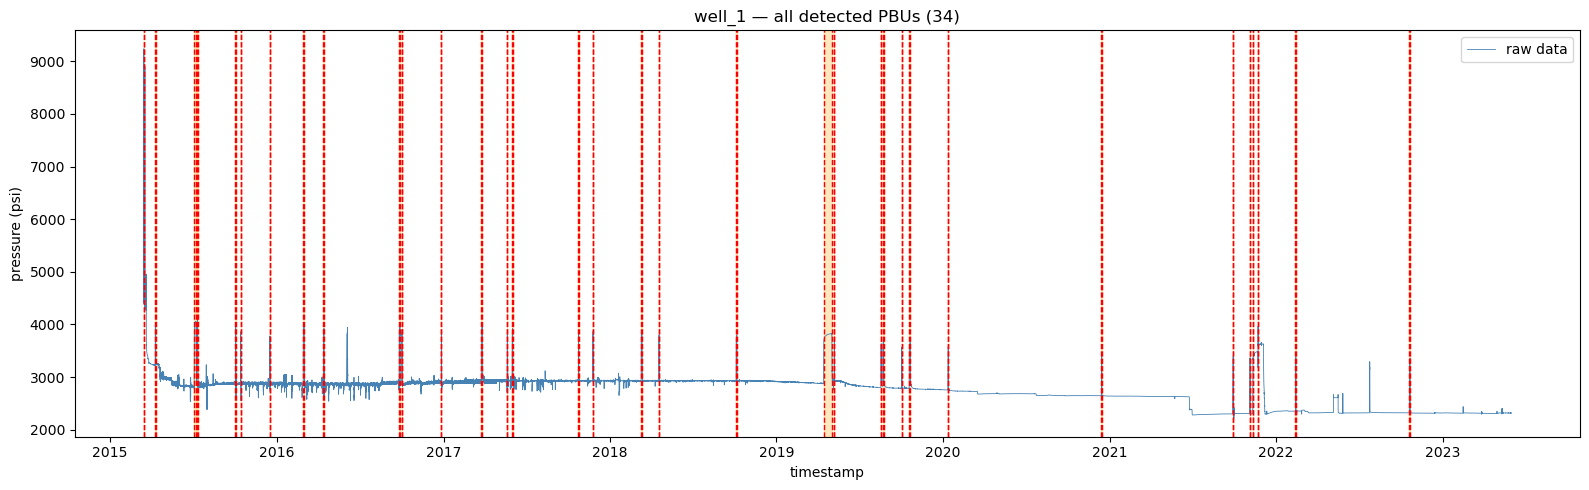

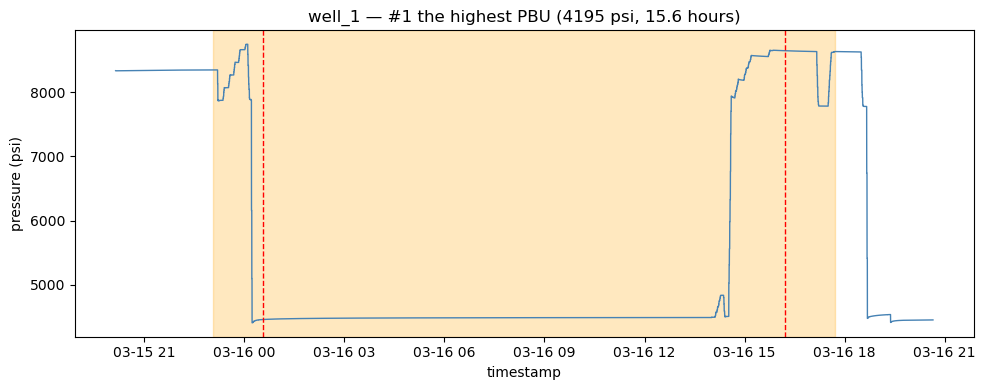

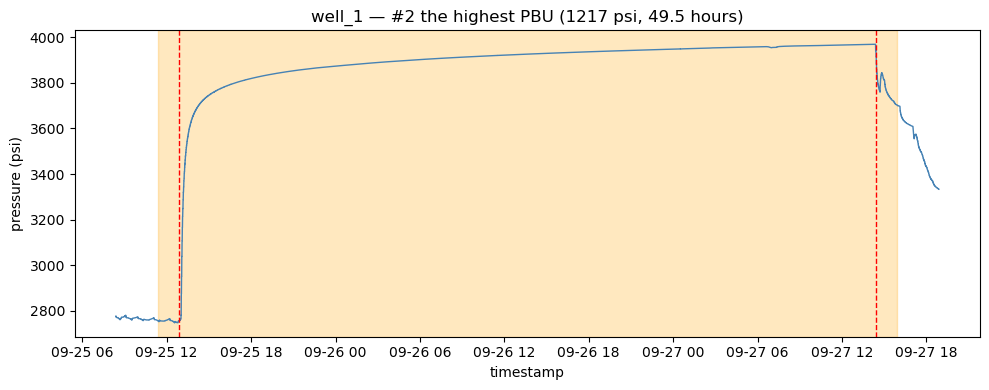

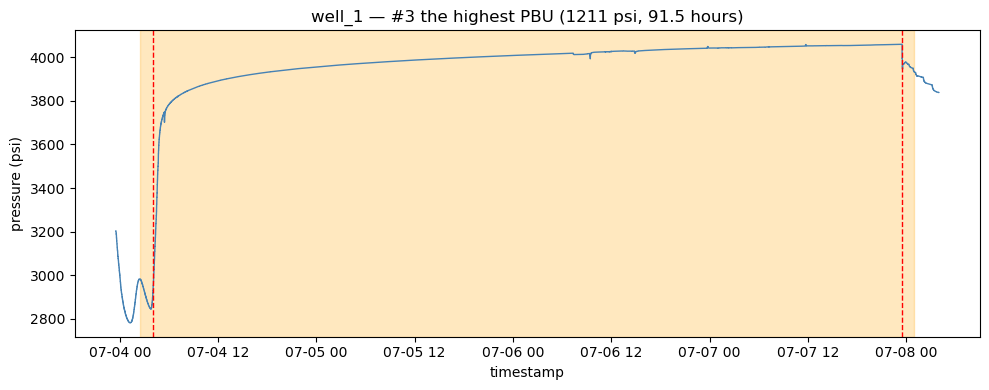

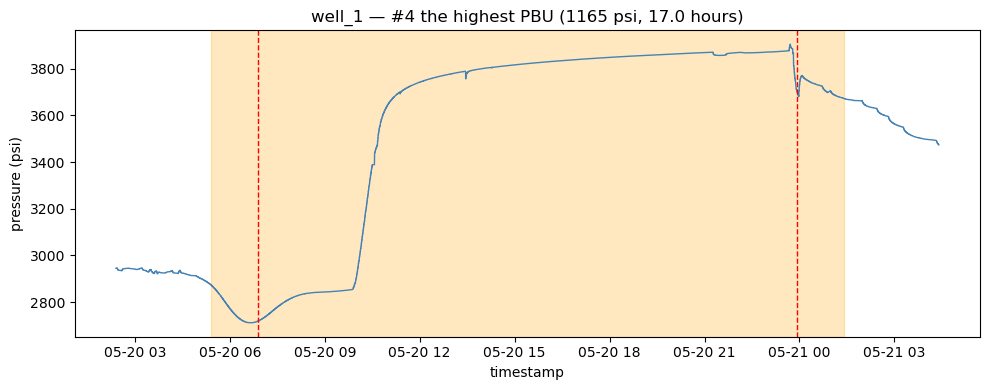

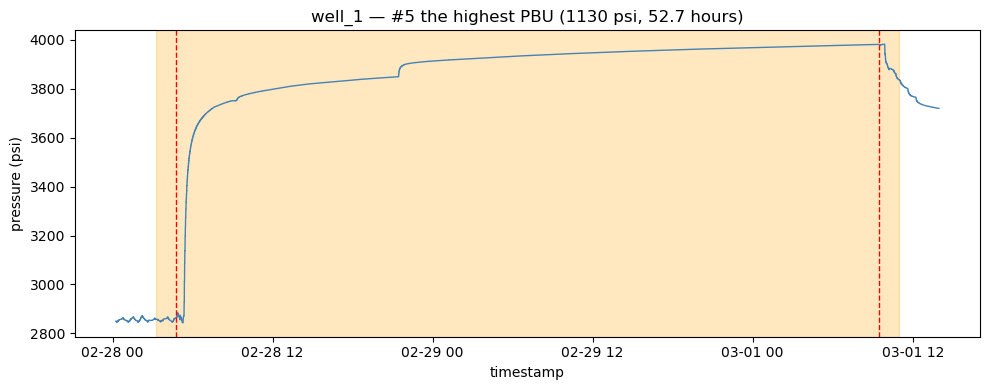

,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_1,2015-03-16 00:33:25.800000+00:00,2015-03-15 23:03:25.800000+00:00,2015-03-16 16:12:06.100000+00:00,2015-03-16 17:42:06.100000+00:00,15.64,"4,194.79"
1,well_1,2015-04-09 14:20:47+00:00,2015-04-09 12:50:47+00:00,2015-04-10 09:58:37.603000+00:00,2015-04-10 11:28:37.603000+00:00,19.63,810.86
2,well_1,2015-07-04 04:01:19.800000+00:00,2015-07-04 02:31:19.800000+00:00,2015-07-07 23:29:58.900000+00:00,2015-07-08 00:59:58.900000+00:00,91.48,"1,211.06"
3,well_1,2015-07-09 18:17:24+00:00,2015-07-09 16:47:24+00:00,2015-07-11 11:15:54.500000+00:00,2015-07-11 12:45:54.500000+00:00,40.98,"1,126.97"
4,well_1,2015-10-02 08:11:20+00:00,2015-10-02 06:41:20+00:00,2015-10-03 06:36:55.336000+00:00,2015-10-03 08:06:55.336000+00:00,22.43,"1,084.45"
5,well_1,2015-10-13 21:54:19.100000+00:00,2015-10-13 20:24:19.100000+00:00,2015-10-14 02:44:20.400000+00:00,2015-10-14 04:14:20.400000+00:00,4.83,996.85
6,well_1,2015-12-16 09:27:29.400000+00:00,2015-12-16 07:57:29.400000+00:00,2015-12-17 04:01:51.300000+00:00,2015-12-17 05:31:51.300000+00:00,18.57,993.63
7,well_1,2016-02-28 04:44:51+00:00,2016-02-28 03:14:51+00:00,2016-03-01 09:27:55.350000+00:00,2016-03-01 10:57:55.350000+00:00,52.72,"1,130.16"
8,well_1,2016-04-11 01:49:21.804000+00:00,2016-04-11 00:19:21.804000+00:00,2016-04-12 21:36:10.304000+00:00,2016-04-12 23:06:10.304000+00:00,43.78,907.98
9,well_1,2016-09-25 12:53:13.700000+00:00,2016-09-25 11:23:13.700000+00:00,2016-09-27 14:23:29.681000+00:00,2016-09-27 15:53:29.681000+00:00,49.50,"1,216.88"



 well_2 is processing (C:\Users\Amin\Downloads\data\data\Section 1\well_02_DHP_data..csv)
rows: 3,350,970 | date range: 2018-09-28 15:50:12+00:00 -> 2023-06-01 03:59:43.011000+00:00
noise level: 0.09 psi -> decline_tol: 15.00 psi
 30 PBUs found for well_2.


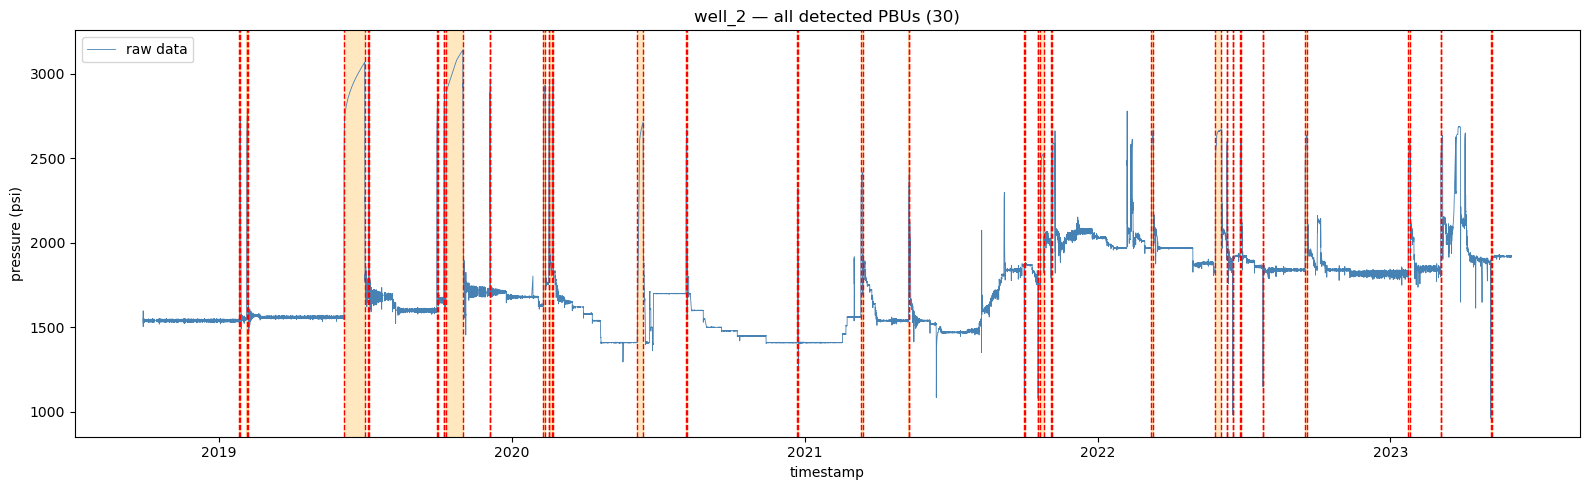

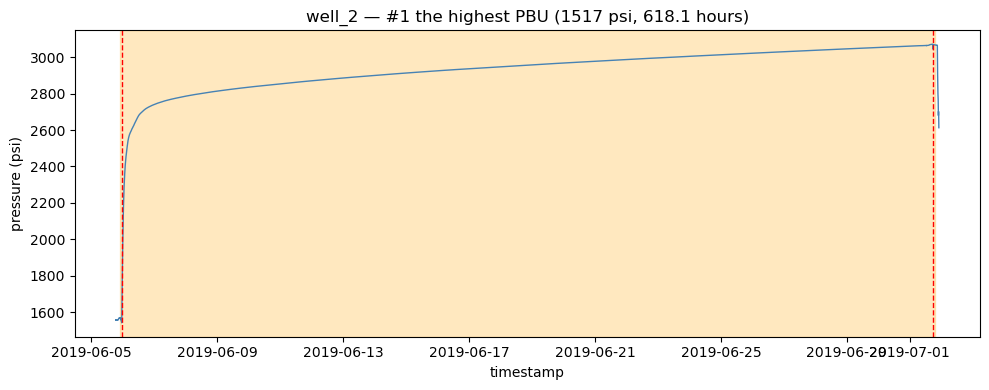

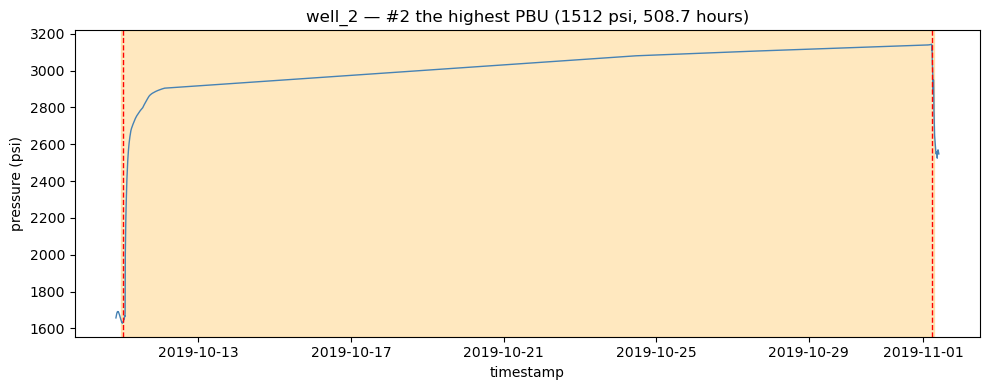

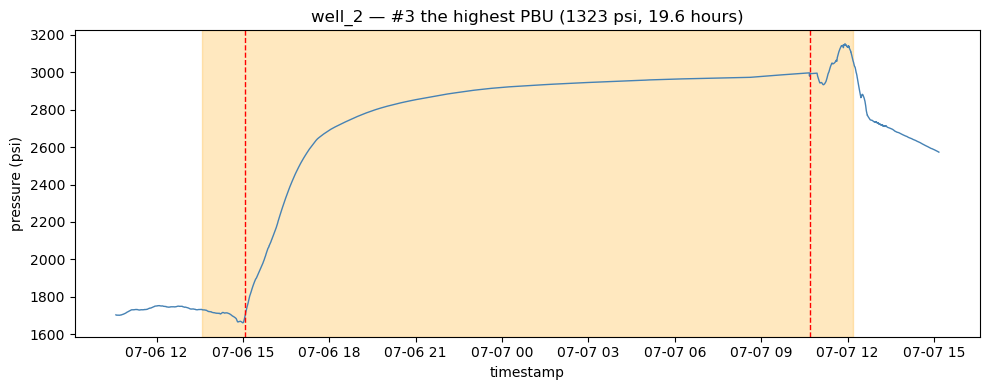

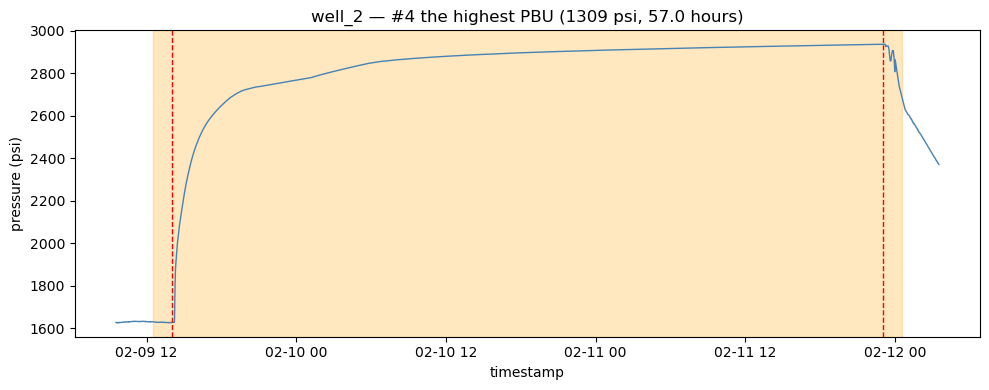

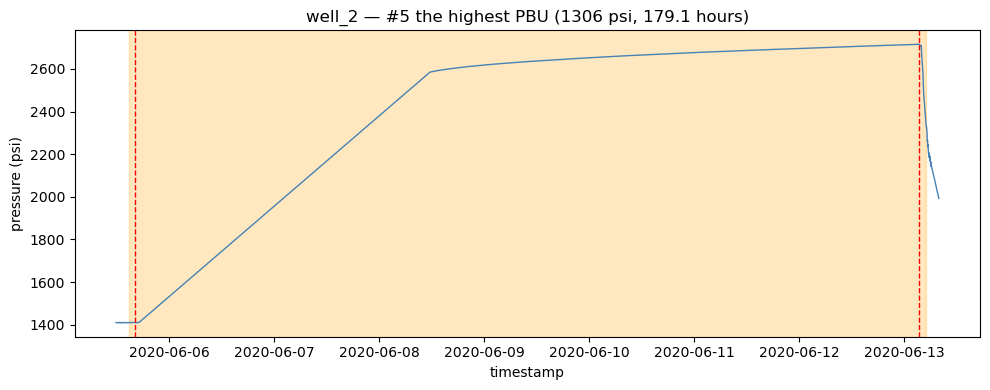

,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_2,2019-01-26 15:26:01+00:00,2019-01-26 13:56:01+00:00,2019-01-27 17:15:26+00:00,2019-01-27 18:45:26+00:00,25.82,"1,205.56"
1,well_2,2019-02-04 12:45:57+00:00,2019-02-04 11:15:57+00:00,2019-02-05 22:45:51+00:00,2019-02-06 00:15:51+00:00,34.00,"1,246.91"
2,well_2,2019-06-05 23:28:06+00:00,2019-06-05 21:58:06+00:00,2019-07-01 17:36:38+00:00,2019-07-01 19:06:38+00:00,618.14,"1,517.44"
3,well_2,2019-07-06 15:05:03+00:00,2019-07-06 13:35:03+00:00,2019-07-07 10:40:37+00:00,2019-07-07 12:10:37+00:00,19.59,"1,323.21"
4,well_2,2019-09-29 16:48:49+00:00,2019-09-29 15:18:49+00:00,2019-10-01 00:31:10+00:00,2019-10-01 02:01:10+00:00,31.71,"1,272.64"
5,well_2,2019-10-08 11:22:24+00:00,2019-10-08 09:52:24+00:00,2019-10-09 04:54:00+00:00,2019-10-09 06:24:00+00:00,17.53,"1,186.22"
6,well_2,2019-10-11 00:36:13+00:00,2019-10-10 23:06:13+00:00,2019-11-01 05:19:10+00:00,2019-11-01 06:49:10+00:00,508.72,"1,512.07"
7,well_2,2019-12-04 16:59:13+00:00,2019-12-04 15:29:13+00:00,2019-12-05 08:17:37+00:00,2019-12-05 09:47:37+00:00,15.31,"1,200.08"
8,well_2,2020-02-09 14:02:16+00:00,2020-02-09 12:32:16+00:00,2020-02-11 23:02:27+00:00,2020-02-12 00:32:27+00:00,57.00,"1,309.31"
9,well_2,2020-02-16 04:20:47+00:00,2020-02-16 02:50:47+00:00,2020-02-17 08:30:41+00:00,2020-02-17 10:00:41+00:00,28.16,"1,193.41"



 well_3 is processing (C:\Users\Amin\Downloads\data\data\Section 1\well_03_DHP_data..csv)
rows: 18,487,157 | date range: 2015-02-18 12:46:26.625000 -> 2024-10-30 13:10:18.731000
noise level: 0.06 psi -> decline_tol: 15.00 psi
 56 PBUs found for well_3.


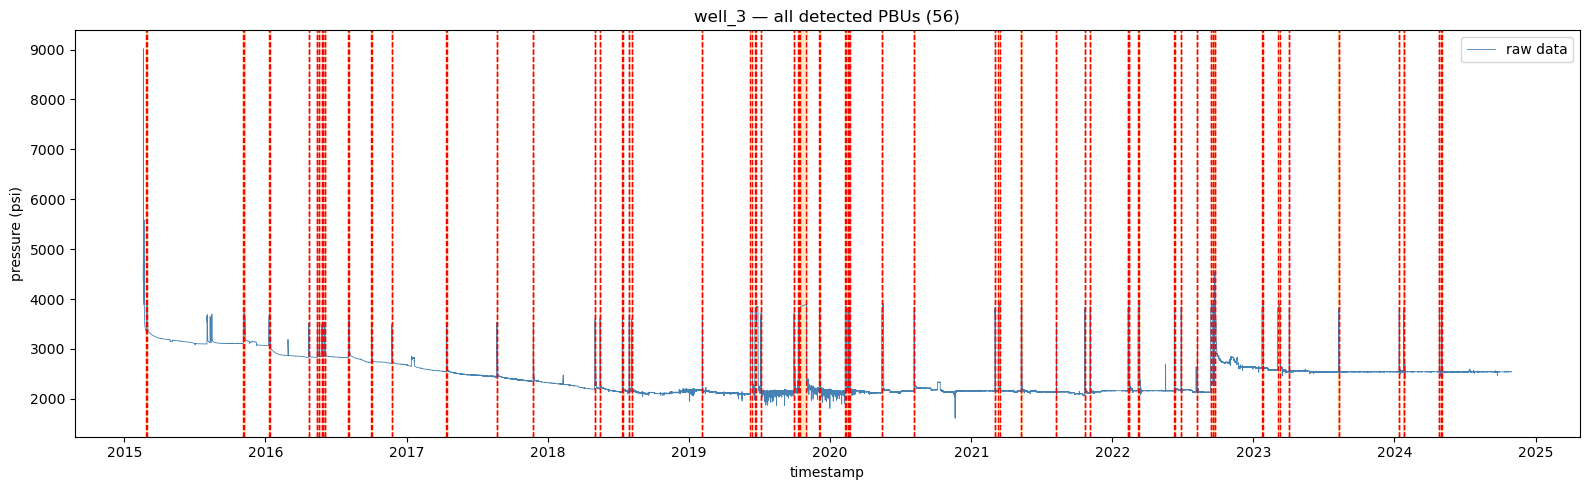

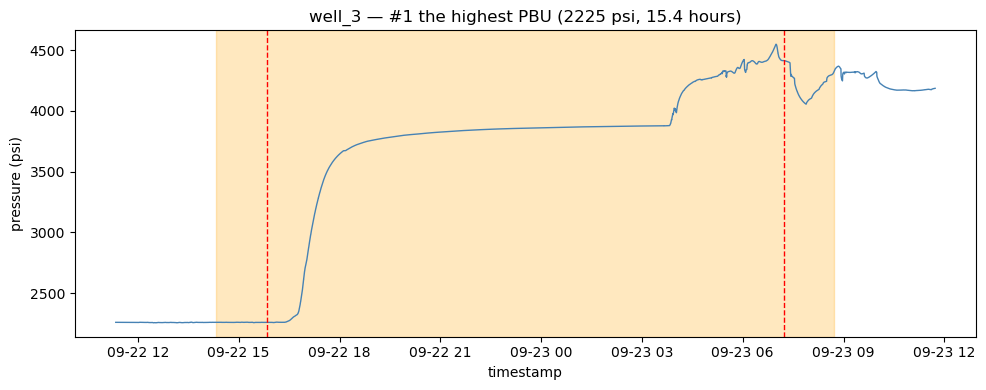

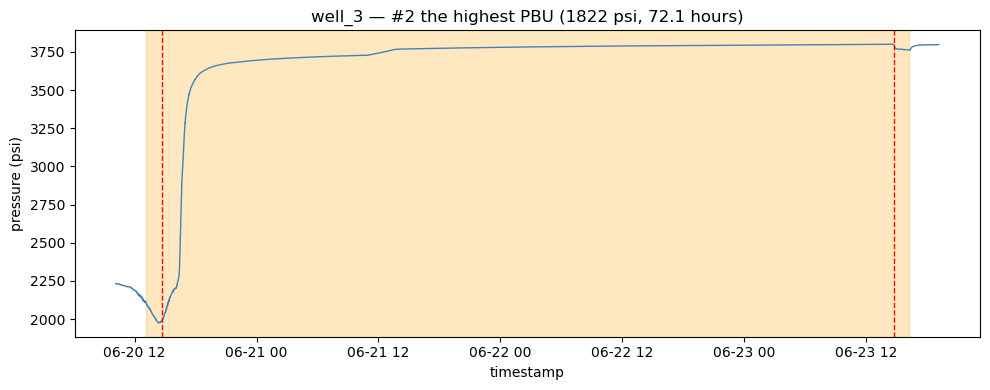

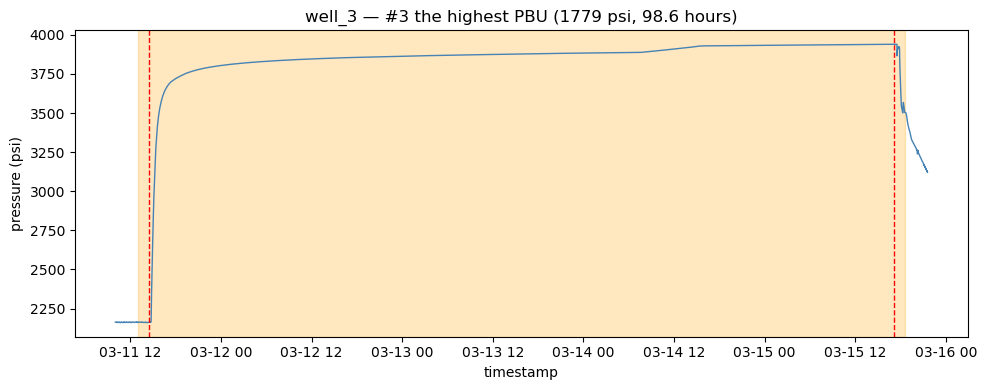

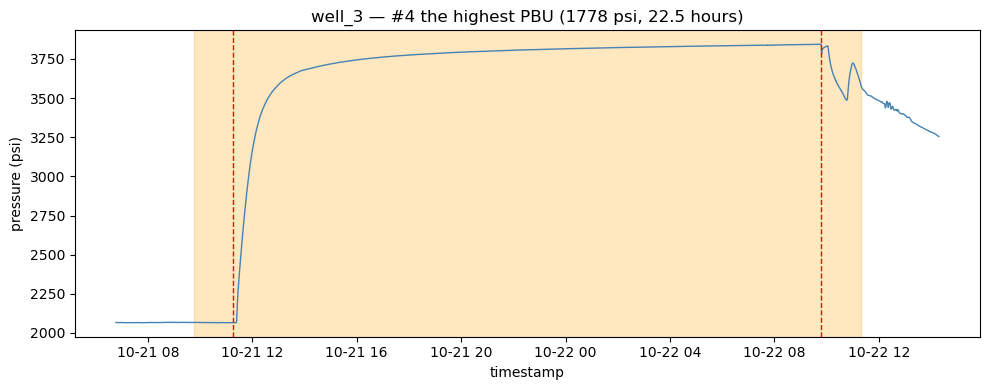

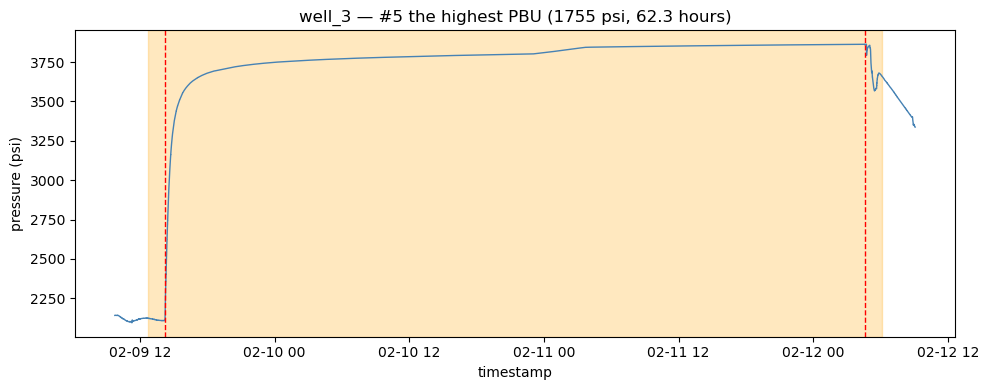

,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_3,2015-02-26 22:02:50.577,2015-02-26 20:32:50.577,2015-02-28 13:15:03.526,2015-02-28 14:45:03.526,39.20,611.21
1,well_3,2015-11-04 16:56:06.900,2015-11-04 15:26:06.900,2015-11-07 16:38:49.600,2015-11-07 18:08:49.600,71.71,616.59
2,well_3,2016-01-09 02:08:37.800,2016-01-09 00:38:37.800,2016-01-12 04:45:20.600,2016-01-12 06:15:20.600,74.61,658.92
3,well_3,2016-04-21 18:38:32.200,2016-04-21 17:08:32.200,2016-04-22 01:19:57.300,2016-04-22 02:49:57.300,6.69,690.21
4,well_3,2016-05-14 07:17:56.400,2016-05-14 05:47:56.400,2016-05-14 10:23:29.300,2016-05-14 11:53:29.300,3.09,625.62
5,well_3,2016-05-19 10:40:19.400,2016-05-19 09:10:19.400,2016-05-19 13:21:20.500,2016-05-19 14:51:20.500,2.68,642.36
6,well_3,2016-05-25 18:36:37.500,2016-05-25 17:06:37.500,2016-05-25 21:12:46.900,2016-05-25 22:42:46.900,2.60,652.46
7,well_3,2016-05-28 00:54:32.800,2016-05-27 23:24:32.800,2016-05-28 07:01:46.300,2016-05-28 08:31:46.300,6.12,686.39
8,well_3,2016-06-02 09:25:50.800,2016-06-02 07:55:50.800,2016-06-02 16:40:46.000,2016-06-02 18:10:46.000,7.25,697.04
9,well_3,2016-08-02 21:16:10.100,2016-08-02 19:46:10.100,2016-08-04 15:11:46.100,2016-08-04 16:41:46.100,41.93,763.38



 cemi 120 PBU (well_1 + well_2 + well_3). results are saved to: pbu_detection_all_wells.csv


,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_1,2015-03-16 00:33:25.800000+00:00,2015-03-15 23:03:25.800000+00:00,2015-03-16 16:12:06.100000+00:00,2015-03-16 17:42:06.100000+00:00,15.64,"4,194.79"
1,well_1,2015-04-09 14:20:47+00:00,2015-04-09 12:50:47+00:00,2015-04-10 09:58:37.603000+00:00,2015-04-10 11:28:37.603000+00:00,19.63,810.86
2,well_1,2015-07-04 04:01:19.800000+00:00,2015-07-04 02:31:19.800000+00:00,2015-07-07 23:29:58.900000+00:00,2015-07-08 00:59:58.900000+00:00,91.48,"1,211.06"
3,well_1,2015-07-09 18:17:24+00:00,2015-07-09 16:47:24+00:00,2015-07-11 11:15:54.500000+00:00,2015-07-11 12:45:54.500000+00:00,40.98,"1,126.97"
4,well_1,2015-10-02 08:11:20+00:00,2015-10-02 06:41:20+00:00,2015-10-03 06:36:55.336000+00:00,2015-10-03 08:06:55.336000+00:00,22.43,"1,084.45"
...,...,...,...,...,...,...,...
115,well_3,2023-08-09 13:22:07,2023-08-09 11:52:07,2023-08-10 16:08:11,2023-08-10 17:38:11,26.77,"1,281.46"
116,well_3,2024-01-13 01:04:19.478000,2024-01-12 23:34:19.478000,2024-01-13 22:55:24.987000,2024-01-14 00:25:24.987000,21.85,"1,284.67"
117,well_3,2024-01-24 19:35:54.059000,2024-01-24 18:05:54.059000,2024-01-25 03:05:11.264000,2024-01-25 04:35:11.264000,7.49,"1,248.99"
118,well_3,2024-04-26 10:39:12.154000,2024-04-26 09:09:12.154000,2024-04-26 15:17:20.860000,2024-04-26 16:47:20.860000,4.64,"1,219.58"


In [3]:
all_results = {}

for cfg in WELL_CONFIGS:
    well_name = cfg['well_name']
    print(f'\n {well_name} is processing ({cfg["file_path"]})')

    df = load_well_data(cfg['file_path'], ts_col=cfg['ts_col'], pr_col=cfg['pr_col'])
    print(f'rows: {len(df):,} | date range: {df.index.min()} -> {df.index.max()}')

    smoothed = smooth_pressure(df)
    noise = estimate_noise_level(smoothed)
    decline_tol = max(min_decline_tol, noise_mult * noise)
    print(f'noise level: {noise:.2f} psi -> decline_tol: {decline_tol:.2f} psi')

    result_df = detect_pbus_zigzag(smoothed, decline_tol=decline_tol)
    result_df = result_df.sort_values('exact_start').reset_index(drop=True)
    result_df.insert(0, 'well', well_name)

    print(f' {len(result_df)} PBUs found for {well_name}.')

    plot_all_pbus(df, result_df, well_name)
    plot_top_pbus(df, result_df, well_name, top_n=5)
    display(result_df)

    all_results[well_name] = result_df
    del df, smoothed

#3 quyunun neticesini bir excel-de birleşdirme
final_table = pd.concat(all_results.values(), ignore_index=True)
final_table.to_csv('pbu_detection_all_wells.csv', index=False)

print(f'\n cemi {len(final_table)} PBU (well_1 + well_2 + well_3). '
      f'results are saved to: pbu_detection_all_wells.csv')
final_table